# 🏡 Task 03 — Feature Engineering Mastery

### Dataset
House Prices - Advanced Regression

### Business Problem

A real estate company wants to improve the accuracy of house price prediction by engineering meaningful features. The objective is to reduce the prediction error (MAE) and provide more reliable house price estimates.

---

## Objectives

- Understand the dataset
- Perform exploratory data analysis
- Clean and preprocess the data
- Engineer meaningful features
- Apply feature selection techniques
- Train and evaluate a regression model
- Compare baseline and improved model performance
- Present findings through visualizations and a professional report

# Step 1: Import Libraries

The following libraries are imported for:

- Data manipulation
- Data visualization
- Feature engineering
- Machine learning
- Model evaluation


In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    PolynomialFeatures
)

from sklearn.feature_selection import (
    mutual_info_regression,
    RFE
)

from sklearn.linear_model import (
    LinearRegression,
    Lasso
)

from sklearn.metrics import mean_absolute_error

# Step 2: Load Dataset

The House Prices dataset is loaded into a Pandas DataFrame for exploration and preprocessing.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train (1).csv to train (1).csv


In [3]:
df = pd.read_csv("train (1).csv")

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.shape

(1460, 81)

## Step 3: Initial Dataset Exploration

The dataset is explored to understand:

- Number of rows and columns
- Feature names
- Data types
- Missing values
- Statistical summary

In [6]:
print("Shape of Dataset:", df.shape)

print("\nFirst Five Rows")
display(df.head())

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

print("\nColumn Names")
display(df.columns)

Shape of Dataset: (1460, 81)

First Five Rows


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



Column Names


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# Step 4:Missing Value Analysis

Missing values can negatively affect machine learning models and feature engineering.

In this section, we identify missing values in each feature to understand which columns require preprocessing before model training.

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


## Observation

The missing value analysis shows that several features contain missing values.

Some columns, such as **PoolQC**, **MiscFeature**, **Alley**, **Fence**, and **FireplaceQu**, have a large number of missing values, while others contain only a few missing entries.

These missing values will be handled appropriately during the data preprocessing stage before feature engineering and model training.

# Step 5: Missing Value Percentage Analysis

After identifying missing values, the next step is to calculate their percentage.

This helps determine the severity of missing data and supports better preprocessing decisions before feature engineering.

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage.sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageFinish,5.547945
GarageType,5.547945


# Step 6: Duplicate Value Analysis

This step checks whether duplicate records exist in the dataset before proceeding with preprocessing and feature engineering.

In [9]:
duplicate_rows = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 0


## Observation

No duplicate records were found in the dataset. Therefore, no duplicate removal is required.

# Step 7: Target Variable Analysis

The target variable represents the value that the machine learning model will predict.

In this project, the target variable is **SalePrice**. Analyzing its statistical properties helps us understand the range and distribution of house prices before building the prediction model.

In [10]:
df["SalePrice"].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


# Step 8: Distribution of the Target Variable

A histogram is used to visualize the distribution of the target variable (**SalePrice**).

Understanding the distribution helps identify skewness and potential outliers before model development.

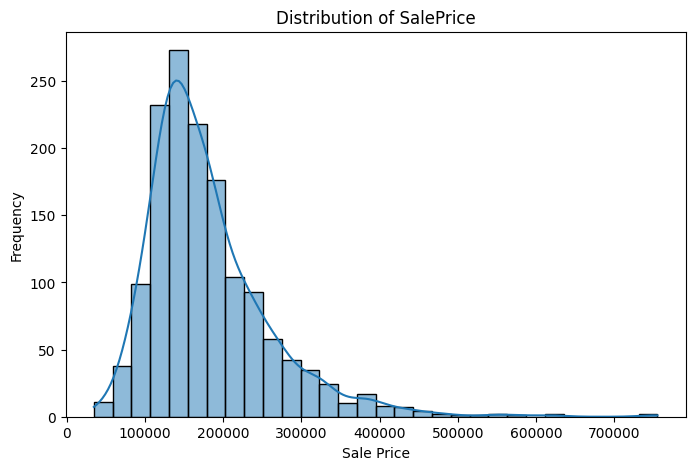

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], bins=30, kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

## Observation

The distribution of **SalePrice** is positively skewed (right-skewed). Most houses are priced between **100,000** and **200,000**, while only a few houses have very high sale prices. This indicates the presence of high-value properties that may influence model performance.

# Step 9: Identify Numerical and Categorical Features

The dataset contains both numerical and categorical features.

Identifying each type helps apply the correct preprocessing and feature engineering techniques in later stages.

In [12]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

categorical_features = df.select_dtypes(include=["object"]).columns

print("Number of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

Number of Numerical Features: 38
Number of Categorical Features: 43


# Step 10: Separate Features and Target Variable

Before building a machine learning model, the dataset is divided into input features (X) and the target variable (y).

The input features contain all predictor variables, while the target variable contains the house sale prices that the model will learn to predict.

In [13]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (1460, 80)
Target Variable Shape: (1460,)


# Step 11: Correlation Analysis

Correlation measures the relationship between numerical features and the target variable (**SalePrice**).

This analysis helps identify the most influential features that may improve the prediction model and guide feature engineering decisions.



In [14]:
correlation = df.corr(numeric_only=True)

saleprice_corr = correlation["SalePrice"].sort_values(ascending=False)

saleprice_corr

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


## Observation

The correlation analysis shows that **OverallQual**, **GrLivArea**, **GarageCars**, **GarageArea**, and **TotalBsmtSF** have the strongest positive relationship with **SalePrice**.

These features are likely to be the most influential predictors and will play an important role during feature engineering and model development.

# Step 12: Correlation Heatmap

A correlation heatmap provides a visual representation of the relationships between numerical features.

It helps identify strongly correlated variables and supports feature selection and engineering decisions.

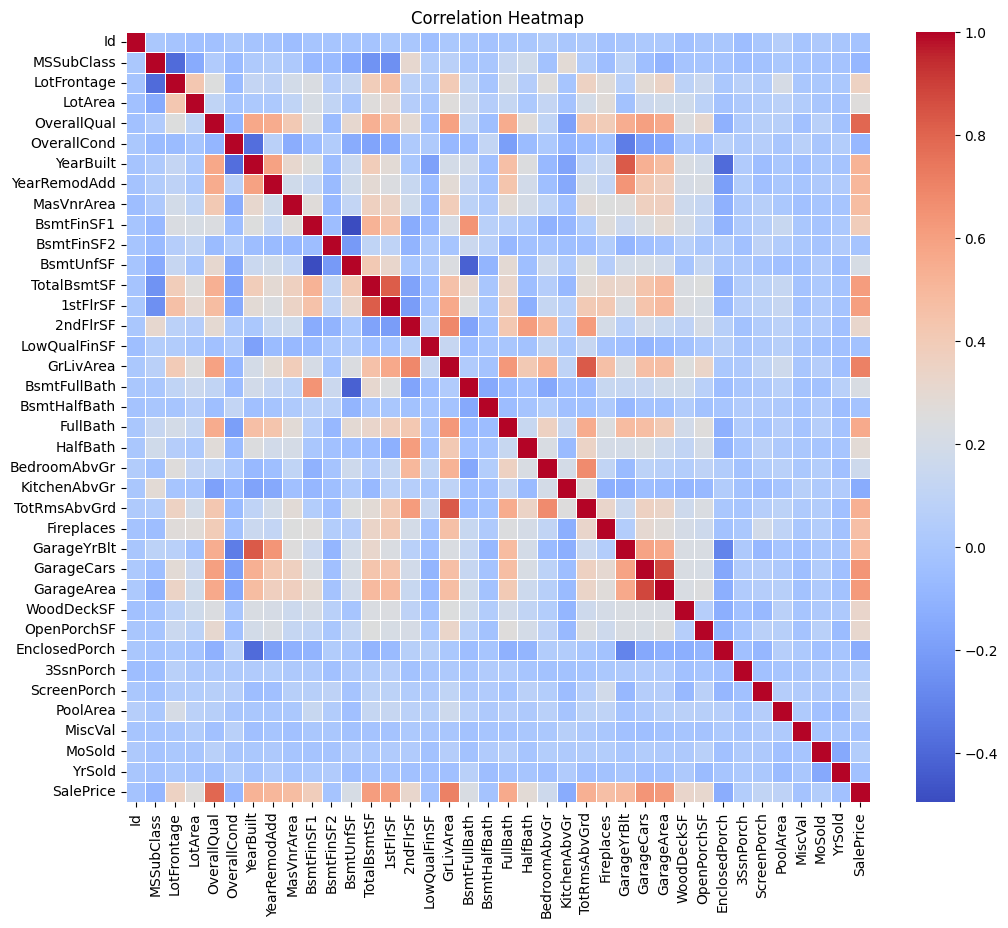

In [15]:
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

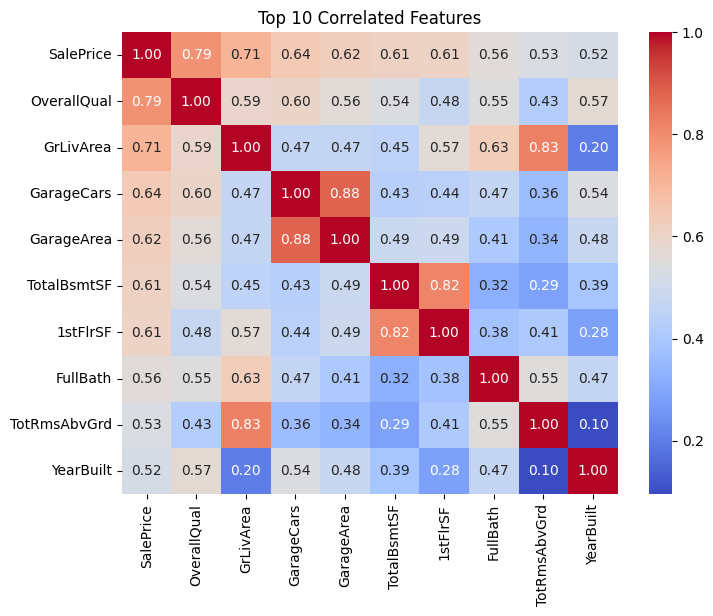

In [16]:
top_features = saleprice_corr.head(10).index

plt.figure(figsize=(8,6))

sns.heatmap(df[top_features].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Top 10 Correlated Features")

plt.show()

# Step 13: Missing Value Handling

Before creating new features, missing values must be handled appropriately.

Different imputation techniques are applied based on the feature type and the meaning of missing values.

In [17]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


## Step 13.1: Fill Missing Categorical Values

Some categorical features contain missing values because the corresponding facility does not exist for that house (e.g., no pool, no garage, or no alley access).

These missing values are replaced with **"None"** to preserve their meaning.

In [18]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

df[none_cols] = df[none_cols].fillna("None")

## Observation

Missing values in categorical features representing the absence of a facility were successfully replaced with **"None"**.

## Step 13.2: Fill Missing Numerical Values

Missing values in numerical features are replaced with the **median** because it is more robust to outliers than the mean.

In [19]:
median_cols = [
    "LotFrontage",
    "GarageYrBlt",
    "MasVnrArea"
]

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

## Observation

Missing values in numerical features were successfully filled using the median value to minimize the impact of outliers.

In [20]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


## Step 13.3: Fill Basement-Related Missing Values

Missing values in basement-related categorical features indicate that the house does not have a basement.

Therefore, these missing values are replaced with **"None"** instead of treating them as unknown values.

In [21]:
bsmt_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

df[bsmt_cols] = df[bsmt_cols].fillna("None")

## Observation

Missing values in basement-related features were replaced with **"None"**, indicating the absence of a basement rather than missing information.

## Step 13.4: Fill Remaining Missing Values

The **Electrical** feature contains only one missing value.

Since it is a categorical feature with a valid value expected for every house, the missing value is replaced using the most frequent category (mode).


In [22]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

## Observation

The missing value in the **Electrical** feature was filled using the most frequent category (mode).

## Step 13.5: Verify Missing Values

Finally, the dataset is checked again to confirm that all missing values have been handled successfully.

In [23]:
df.isnull().sum().sum()

np.int64(0)

# Step 14: Feature Creation

Feature engineering involves creating new features from existing variables to provide more meaningful information to the machine learning model.

The first engineered feature is **HouseAge**, which represents the age of the house at the time it was sold.


## Step 14.1: Create HouseAge

The **HouseAge** feature is created by subtracting the construction year (**YearBuilt**) from the selling year (**YrSold**).

Instead of using the construction year directly, the age of the house at the time of sale provides more meaningful information for predicting house prices.

**Formula:**

HouseAge = YrSold − YearBuilt

In [24]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

df[["YearBuilt", "YrSold", "HouseAge"]].head()

,YearBuilt,YrSold,HouseAge
0,2003,2008,5
1,1976,2007,31
2,2001,2008,7
3,1915,2006,91
4,2000,2008,8


### Observation

A new feature named **HouseAge** was successfully created.

This feature represents the age of each house when it was sold. It is expected to be more informative than using the construction year alone and may improve the model's predictive performance.

## Step 14.2: Create TotalBathrooms

The total number of bathrooms is an important factor influencing house prices.

Instead of keeping multiple bathroom-related features separately, they are combined into a single feature called **TotalBathrooms**. This provides a better representation of the overall bathroom capacity of a house.

**Formula:**

TotalBathrooms = FullBath + (0.5 × HalfBath) + BsmtFullBath + (0.5 × BsmtHalfBath)

In [25]:
df["TotalBathrooms"] = (
    df["FullBath"]
    + (0.5 * df["HalfBath"])
    + df["BsmtFullBath"]
    + (0.5 * df["BsmtHalfBath"])
)

df[["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath", "TotalBathrooms"]].head()

,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,TotalBathrooms
0,2,1,1,0,3.5
1,2,0,0,1,2.5
2,2,1,1,0,3.5
3,1,0,1,0,2.0
4,2,1,1,0,3.5


### Observation

The **TotalBathrooms** feature combines all bathroom-related information into a single variable. This engineered feature provides a more complete representation of the house and is expected to be more useful for predicting **SalePrice** than using separate bathroom features.

## Step 14.3: Create TotalPorchSF

The dataset contains multiple porch-related features. These are combined into a single feature called **TotalPorchSF**, representing the total porch area of a house.

Combining related features simplifies the dataset and captures the overall outdoor living space more effectively.

In [26]:
df["TotalPorchSF"] = (
    df["OpenPorchSF"]
    + df["EnclosedPorch"]
    + df["3SsnPorch"]
    + df["ScreenPorch"]
)

df[["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "TotalPorchSF"]].head()

,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,TotalPorchSF
0,61,0,0,0,61
1,0,0,0,0,0
2,42,0,0,0,42
3,35,272,0,0,307
4,84,0,0,0,84


## Step 14.4: Create TotalSF

The total living space of a house is calculated by combining the basement area, first-floor area, and second-floor area.

This engineered feature provides a better estimate of the overall house size, which is expected to have a strong influence on **SalePrice**.

**Formula:**

TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF

In [27]:
df["TotalSF"] = (
    df["TotalBsmtSF"]
    + df["1stFlrSF"]
    + df["2ndFlrSF"]
)

df[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


### Observation

The **TotalSF** feature represents the overall usable area of the house by combining the basement, first floor, and second floor areas. Since house size is one of the strongest factors affecting **SalePrice**, this engineered feature is expected to improve the model's predictive performance.

# Step 15: Feature Transformation (Binning)

Feature transformation improves data representation before model training.

One common transformation technique is **binning**, where continuous numerical values are converted into meaningful categories.

In this step, the **HouseAge** feature is grouped into different age categories.

## Step 15.1: Create HouseAgeGroup

The **HouseAge** feature is divided into different age groups.

Grouping houses based on age makes the data easier to interpret and may help machine learning models capture meaningful patterns.

In [28]:
df["HouseAgeGroup"] = pd.cut(
    df["HouseAge"],
    bins=[0, 10, 30, 60, 150],
    labels=["New", "Moderate", "Old", "Very Old"]
)

df[["HouseAge", "HouseAgeGroup"]].head()

,HouseAge,HouseAgeGroup
0,5,New
1,31,Old
2,7,New
3,91,Very Old
4,8,New


### Observation

A new categorical feature named **HouseAgeGroup** was created by grouping houses according to their age.

This transformation improves interpretability and may help capture age-related patterns during model training.

## Step 15.2: Analyze HouseAgeGroup Distribution

The distribution of the newly created age groups is examined to understand how houses are spread across different categories.


In [29]:
df["HouseAgeGroup"].value_counts()

,count
HouseAgeGroup,
Old,526
New,370
Very Old,292
Moderate,208


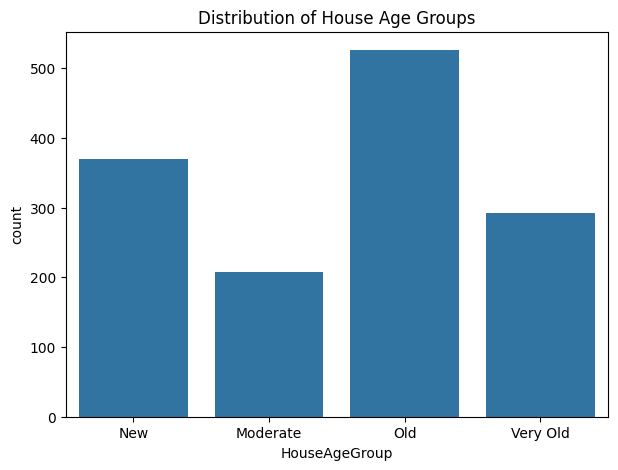

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="HouseAgeGroup")

plt.title("Distribution of House Age Groups")

plt.show()

### Observation

The distribution shows how many houses belong to each age category. This provides a better understanding of the housing stock and confirms that the engineered feature contains meaningful groups for further analysis.

# Step 16: Polynomial Feature Engineering

Polynomial features create new variables by combining existing numerical features.

These features help machine learning models capture non-linear relationships and interactions between variables, potentially improving prediction performance.

In this task, polynomial features are generated using the most important numerical features.

## Step 16.1: Select Important Numerical Features

Instead of generating polynomial features for the entire dataset, only the most relevant numerical features are selected.

This reduces unnecessary complexity while preserving useful interactions.

In [31]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = df[["OverallQual", "GrLivArea"]]

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

poly_data = poly.fit_transform(poly_features)

poly_df = pd.DataFrame(
    poly_data,
    columns=poly.get_feature_names_out(poly_features.columns)
)

poly_df.head()

,OverallQual,GrLivArea,OverallQual^2,OverallQual GrLivArea,GrLivArea^2
0,7.0,1710.0,49.0,11970.0,2924100.0
1,6.0,1262.0,36.0,7572.0,1592644.0
2,7.0,1786.0,49.0,12502.0,3189796.0
3,7.0,1717.0,49.0,12019.0,2948089.0
4,8.0,2198.0,64.0,17584.0,4831204.0


### Observation

Polynomial transformation generated additional interaction features between **OverallQual** and **GrLivArea**.

These new features allow machine learning models to capture more complex relationships that may not be represented by the original variables alone.

## Step 16.2: Examine Generated Polynomial Features

The newly created polynomial features are displayed to verify that interaction and squared terms have been generated correctly.

In [32]:
poly_df.head()

,OverallQual,GrLivArea,OverallQual^2,OverallQual GrLivArea,GrLivArea^2
0,7.0,1710.0,49.0,11970.0,2924100.0
1,6.0,1262.0,36.0,7572.0,1592644.0
2,7.0,1786.0,49.0,12502.0,3189796.0
3,7.0,1717.0,49.0,12019.0,2948089.0
4,8.0,2198.0,64.0,17584.0,4831204.0


# Step 17: Encoding Categorical Features

Machine learning algorithms cannot directly process categorical (text) values.

Therefore, categorical features are converted into numerical representations using **One-Hot Encoding**.

One-Hot Encoding creates separate binary columns for each category while preserving the original information without introducing artificial ordering.


## Step 17.1: Apply One-Hot Encoding

All categorical features are identified and transformed into numerical format using **One-Hot Encoding**.

This prepares the dataset for machine learning algorithms while avoiding ordinal bias.

In [33]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print("Original Shape :", df.shape)
print("Encoded Shape :", df_encoded.shape)

Original Shape : (1460, 86)
Encoded Shape : (1460, 268)


### Observation

All categorical features were successfully converted into numerical format using **One-Hot Encoding**.

The number of columns increased because each category was transformed into a separate binary feature, making the dataset suitable for machine learning models.

## Step 17.2: Verify Encoded Dataset

The shape of the encoded dataset is checked to confirm that categorical variables have been successfully transformed into numerical features.

In [34]:
df_encoded.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,HouseAgeGroup_Moderate,HouseAgeGroup_Old,HouseAgeGroup_Very Old
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,True,False,False,False,True,False,False,False,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,True,False,False,False,True,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,True,False,False,False,True,False,False,False,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,True,False,False,False,False,False,False,False,True
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,True,False,False,False,True,False,False,False,False


# Step 18: Feature Selection

After feature engineering and encoding, the dataset contains a large number of features.

Not every feature contributes equally to predicting house prices. Therefore, feature selection is performed to identify the most informative features while reducing unnecessary complexity.

In this step, different feature selection techniques are applied to evaluate feature importance.

## Step 18.1: Separate Features and Target Variable

The dataset is divided into input features (**X**) and the target variable (**y**).

For this project, **SalePrice** is selected as the target variable because the objective is to predict house prices.


In [36]:
X = df_encoded.drop("SalePrice", axis=1)
y = df_encoded["SalePrice"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (1460, 267)
Target Shape: (1460,)


### Observation

The dataset was successfully divided into input features (**X**) and the target variable (**SalePrice**). This prepares the data for feature selection and machine learning model development.


## Step 18.2: Mutual Information Analysis

Mutual Information measures how much useful information each feature provides about the target variable.

Higher scores indicate stronger relationships with **SalePrice**, helping identify the most informative features.

In [37]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_scores = pd.Series(mi_scores, index=X.columns)

mi_scores = mi_scores.sort_values(ascending=False)

mi_scores.head(10)

,0
TotalSF,0.676543
OverallQual,0.552589
GrLivArea,0.480994
YearBuilt,0.377144
TotalBsmtSF,0.368732
GarageArea,0.359671
TotalBathrooms,0.354614
GarageCars,0.349673
HouseAge,0.337545
1stFlrSF,0.308275


### Observation

The Mutual Information scores identified the most informative features for predicting **SalePrice**. Features with higher scores are expected to contribute more to the machine learning model.

## Step 18.3: Visualize Top Features

The top-ranked features based on Mutual Information scores are visualized to better understand their relative importance.

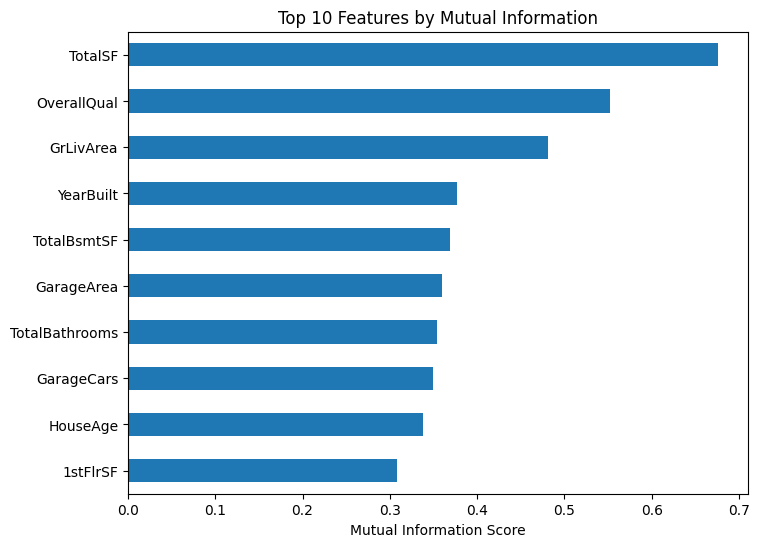

In [38]:
plt.figure(figsize=(8,6))

mi_scores.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Features by Mutual Information")

plt.xlabel("Mutual Information Score")

plt.show()

### Observation

The visualization highlights the features that provide the most information about **SalePrice**. These features are strong candidates for building an effective prediction model.

## Step 18.4: Recursive Feature Elimination (RFE)

Recursive Feature Elimination (RFE) is a wrapper-based feature selection technique that repeatedly trains a model and removes the least important features.

RFE is used to identify a smaller subset of features that provides useful predictive information while reducing model complexity.

In [39]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

rfe_model = LinearRegression()

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=20
)

rfe.fit(X, y)

rfe_features = X.columns[rfe.support_]

print("Selected Features:")
print(rfe_features.tolist())

Selected Features:
['RoofMatl_CompShg', 'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_Roll', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShake', 'RoofMatl_WdShngl', 'ExterQual_Fa', 'ExterQual_Gd', 'ExterQual_TA', 'GarageQual_Fa', 'GarageQual_Po', 'GarageQual_TA', 'GarageCond_Fa', 'GarageCond_Gd', 'GarageCond_Po', 'GarageCond_TA', 'PoolQC_Fa', 'PoolQC_Gd', 'PoolQC_None']


### Observation

RFE selected 20 features from the encoded feature set. The selected features mainly represent roof material, exterior quality, garage quality and condition, and pool quality categories.

This demonstrates that RFE can reduce the feature space to a smaller subset of model-selected features. However, the selected subset depends on the estimator and the number of features specified for selection.

## Step 18.5: L1 Regularization for Feature Selection

L1 regularization, commonly used with Lasso regression, can perform feature selection by shrinking the coefficients of less important features toward zero.

Features with non-zero coefficients are retained as potentially useful predictors, while features whose coefficients become zero can be removed from the model.

## Step 18.5.1: Split the Dataset

The dataset is divided into training and testing sets before applying L1-based feature selection.

This prevents information from the test set from influencing feature selection and helps avoid data leakage.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (1168, 267)
Testing Features: (292, 267)


## Step 18.5.2: Standardize Numerical Features

L1 regularization is sensitive to feature scale. Therefore, the input features are standardized so that features with larger numerical ranges do not dominate the regularization process.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 18.5.3: Apply L1 Regularization

Lasso regression with L1 regularization is used to identify features with non-zero coefficients.

Features whose coefficients are reduced to zero are considered less useful by the model and can be excluded from the selected feature set.

In [44]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, max_iter=10000)

lasso.fit(X_train_scaled, y_train)

lasso_coefficients = pd.Series(
    lasso.coef_,
    index=X_train.columns
)

selected_l1_features = lasso_coefficients[
    lasso_coefficients != 0
].index

print("Number of selected features:", len(selected_l1_features))
print("\nSelected Features:")
print(selected_l1_features.tolist())

Number of selected features: 264

Selected Features:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'HouseAge', 'TotalBathrooms', 'TotalPorchSF', 'TotalSF', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Pave', 'Alley_None', 'Alley_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_NoSeWa', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blueste', 'Neighborhood_BrDale',

## Step 18.5.4: Adjust L1 Regularization Strength

The initial Lasso model retained most of the available features, indicating that the selected regularization strength was not sufficiently restrictive.

A stronger regularization value is therefore tested to encourage more coefficients to shrink toward zero and obtain a more compact feature set.


In [45]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=100, max_iter=10000)

lasso.fit(X_train_scaled, y_train)

lasso_coefficients = pd.Series(
    lasso.coef_,
    index=X_train.columns
)

selected_l1_features = lasso_coefficients[
    lasso_coefficients != 0
].index

print("Number of selected features:", len(selected_l1_features))
print("\nSelected Features:")
print(selected_l1_features.tolist())


Number of selected features: 192

Selected Features:
['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', '2ndFlrSF', 'GrLivArea', 'BsmtHalfBath', 'FullBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MoSold', 'HouseAge', 'TotalBathrooms', 'TotalPorchSF', 'TotalSF', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'Street_Pave', 'Alley_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_NoSeWa', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', '

### Observation

With stronger L1 regularization, the number of selected features decreased from 264 to 192. This shows that L1 regularization removed 75 less-informative features by shrinking their coefficients to zero, resulting in a more compact feature set.

## Step 18.6: Feature Importance Analysis

Feature importance analysis is used to understand which features contribute most strongly to predicting house prices.

The importance of the selected features is examined using their L1 model coefficients. Larger absolute coefficients indicate a stronger contribution to the model, while the sign indicates the direction of the relationship.

In [46]:
l1_importance = (
    lasso_coefficients[selected_l1_features]
    .abs()
    .sort_values(ascending=False)
)

l1_importance.head(10)

,0
PoolArea,87995.070139
PoolQC_None,72658.820741
PoolQC_Gd,22019.098519
TotalSF,16348.659963
PoolQC_Fa,13220.863248
KitchenQual_TA,11191.838433
KitchenQual_Gd,10781.380085
GrLivArea,10629.257416
OverallQual,10133.799014
BsmtQual_Gd,9816.137051


### Observation

The L1 coefficient analysis identified **PoolArea, PoolQC_None, PoolQC_Gd, TotalSF, and PoolQC_Fa** among the strongest features based on absolute coefficient magnitude. Other highly ranked features included **KitchenQual, GrLivArea, OverallQual, and BsmtQual**.

These results indicate that house size, overall quality, kitchen quality, basement quality, and pool-related characteristics contribute strongly to the Lasso model's predictions. The coefficients represent model-based importance and should not be interpreted as direct causal relationships.


## Step 18.7: Visualize L1 Feature Importance

The top 10 features identified by L1 regularization are visualized using their absolute coefficient values. This provides a clearer comparison of their relative importance in the Lasso model.

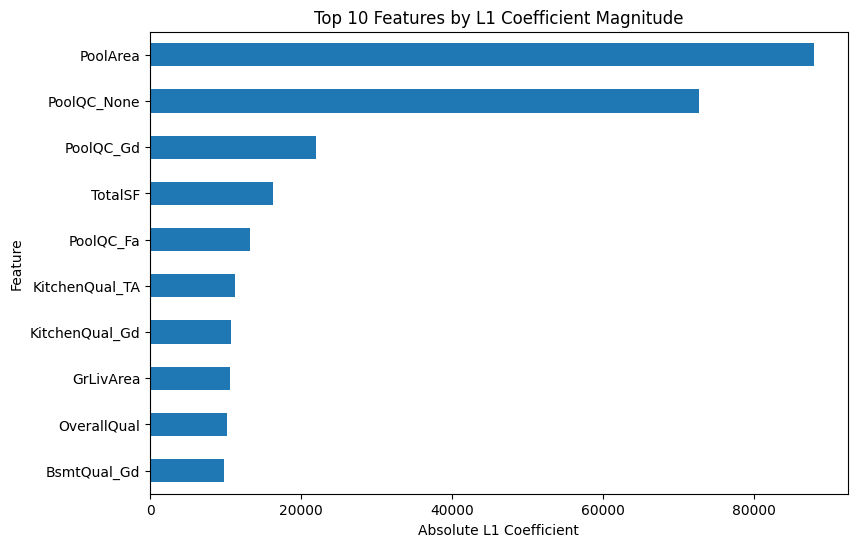

In [47]:
top_l1 = l1_importance.head(10).sort_values()

plt.figure(figsize=(9, 6))

top_l1.plot(kind="barh")

plt.title("Top 10 Features by L1 Coefficient Magnitude")
plt.xlabel("Absolute L1 Coefficient")
plt.ylabel("Feature")

plt.show()

## Step 19.1: Train the Baseline Model

A Random Forest Regressor is used as the baseline model. The baseline provides a reference point for measuring the improvement achieved through feature engineering.

The model is evaluated using MAE, RMSE, and R².

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 17855.863664383563
Baseline RMSE: 30036.678825364696
Baseline R²: 0.8823776133519922


### Observation

The baseline Random Forest model achieved an MAE of **$17,855.86**, which is below the business target of **$18,000**. This indicates that the baseline model already meets the required prediction-error threshold.

The model achieved an RMSE of **$30,036.68** and an R² score of **0.8824**, indicating strong predictive performance while also suggesting the presence of some larger prediction errors.


## Step 19.2: Train the Feature-Selected Model

The features selected through L1 regularization are used to train a second Random Forest Regressor.

The performance of this model is compared with the baseline model to determine whether reducing the feature space can maintain or improve predictive performance while reducing model complexity.

In [49]:
selected_features = selected_l1_features.tolist()

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

selected_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

selected_model.fit(X_train_selected, y_train)

selected_pred = selected_model.predict(X_test_selected)

selected_mae = mean_absolute_error(y_test, selected_pred)
selected_rmse = mean_squared_error(y_test, selected_pred) ** 0.5
selected_r2 = r2_score(y_test, selected_pred)

print("Feature-Selected MAE:", selected_mae)
print("Feature-Selected RMSE:", selected_rmse)
print("Feature-Selected R²:", selected_r2)

Feature-Selected MAE: 17448.276746575342
Feature-Selected RMSE: 29588.886777007123
Feature-Selected R²: 0.8858585414682627


## Step 19.3: Baseline vs Feature-Selected Model Comparison

The baseline and feature-selected Random Forest models are compared using MAE, RMSE, and R².

The comparison evaluates whether feature selection improves predictive performance while reducing the number of input features.

In [50]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Feature-Selected"],
    "Features": [X_train.shape[1], X_train_selected.shape[1]],
    "MAE": [baseline_mae, selected_mae],
    "RMSE": [baseline_rmse, selected_rmse],
    "R2": [baseline_r2, selected_r2]
})

comparison

,Model,Features,MAE,RMSE,R2
0,Baseline,267,17855.863664,30036.678825,0.882378
1,Feature-Selected,192,17448.276747,29588.886777,0.885859


## Step 19.4: Calculate Performance Improvement

The percentage improvement in MAE is calculated to quantify the impact of feature selection on prediction accuracy.

In [51]:
mae_improvement = baseline_mae - selected_mae

mae_improvement_percent = (
    mae_improvement / baseline_mae
) * 100

feature_reduction_percent = (
    (X_train.shape[1] - X_train_selected.shape[1])
    / X_train.shape[1]
) * 100

print("MAE Improvement: $", round(mae_improvement, 2))
print("MAE Improvement (%):", round(mae_improvement_percent, 2), "%")
print("Feature Reduction (%):", round(feature_reduction_percent, 2), "%")

MAE Improvement: $ 407.59
MAE Improvement (%): 2.28 %
Feature Reduction (%): 28.09 %


### Observation

The feature-selected model reduced MAE from **$17,855.86** to **$17,448.28**, representing an improvement of approximately **2.28%**.

The number of features was reduced from **267 to 192**, a reduction of approximately **28.09%**. RMSE also decreased from **$30,036.68** to **$29,588.89**, while R² improved from **0.8824** to **0.8859**.

The final MAE of **$17,448.28** is below the business target of **$18,000**, indicating that the required prediction-error target was achieved.

## Step 19.5: Actual vs Predicted House Prices

The actual and predicted house prices are visualized to assess how closely the model's predictions follow the true SalePrice values.

Points closer to the diagonal reference line indicate more accurate predictions.

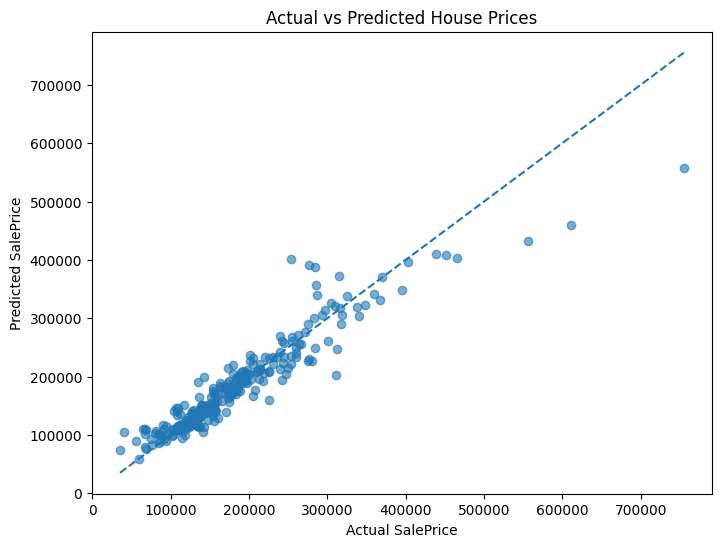

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, selected_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Step 19.6: Prediction Error Analysis

Prediction errors are analyzed to understand how the model's predictions differ from the actual house prices.

Residuals are calculated as the difference between actual and predicted prices. This helps identify patterns and unusually large prediction errors that may affect overall model performance.

In [53]:
residuals = y_test - selected_pred

print("Mean Residual:", residuals.mean())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Mean Residual: 153.60886986301358
Minimum Residual: -147439.93
Maximum Residual: 197279.83499999996


## Step 19.6.1: Residual Distribution

The distribution of prediction errors is visualized to examine whether the model's errors are centered around zero and to identify unusually large errors.

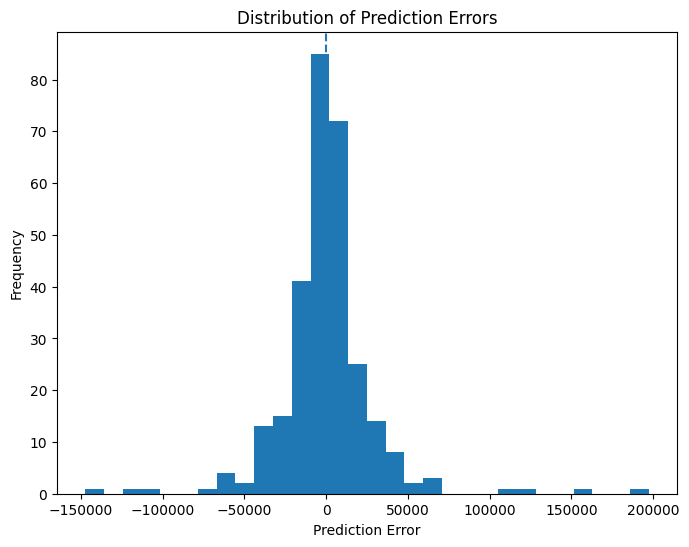

In [54]:
plt.figure(figsize=(8, 6))

plt.hist(residuals, bins=30)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

### Observation

The residuals are mainly concentrated around zero, indicating that most predictions are relatively close to the actual SalePrice values. However, a small number of observations have large positive and negative residuals, indicating that the model still makes larger prediction errors for some houses.

## Step 19.7: Final Model Feature Importance

Feature importance from the final Random Forest model is analyzed to identify which selected features contribute most to the model's predictions.

This analysis helps connect the machine learning results with the real-estate business context.

In [55]:
feature_importance = pd.Series(
    selected_model.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

feature_importance.head(10)

,0
TotalSF,0.389279
OverallQual,0.374251
2ndFlrSF,0.026728
HouseAge,0.023216
YearRemodAdd,0.013983
LotArea,0.013784
GarageCars,0.013592
TotalBathrooms,0.013525
BsmtFinSF1,0.013416
GrLivArea,0.013322


## Step 19.7.1: Visualize Final Feature Importance

The top 10 features from the final Random Forest model are visualized to compare their relative importance in predicting house prices.

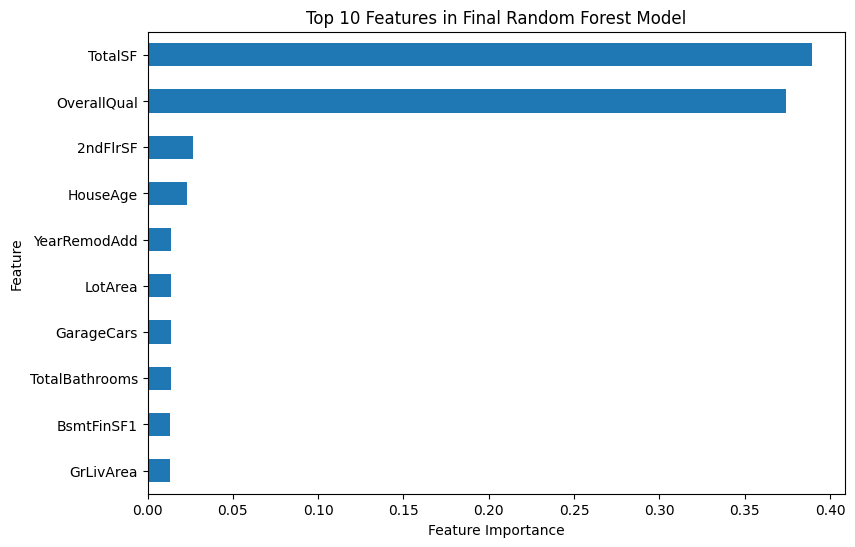

In [56]:
top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(9, 6))

top_features.plot(kind="barh")

plt.title("Top 10 Features in Final Random Forest Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [57]:
feature_importance.head(10)

,0
TotalSF,0.389279
OverallQual,0.374251
2ndFlrSF,0.026728
HouseAge,0.023216
YearRemodAdd,0.013983
LotArea,0.013784
GarageCars,0.013592
TotalBathrooms,0.013525
BsmtFinSF1,0.013416
GrLivArea,0.013322


### Observation

The final Random Forest model identified **TotalSF** and **OverallQual** as the two most important features, with importance scores of approximately **0.389** and **0.374**, respectively.

Other influential features included **2ndFlrSF, HouseAge, YearRemodAdd, LotArea, GarageCars, TotalBathrooms, BsmtFinSF1, and GrLivArea**. The results indicate that property size, overall quality, age, lot size, garage capacity, bathrooms, and finished areas contribute substantially to house-price prediction.

## Step 19.8: Final Model Performance Comparison

The baseline and feature-selected models are compared using their predictive performance and feature counts.

This comparison demonstrates the effect of feature selection on model accuracy and complexity.

In [58]:
final_results = pd.DataFrame({
    "Metric": [
        "Number of Features",
        "MAE",
        "RMSE",
        "R²"
    ],
    "Baseline": [
        X_train.shape[1],
        baseline_mae,
        baseline_rmse,
        baseline_r2
    ],
    "Feature-Selected": [
        X_train_selected.shape[1],
        selected_mae,
        selected_rmse,
        selected_r2
    ]
})

final_results

,Metric,Baseline,Feature-Selected
0,Number of Features,267.000000,192.000000
1,MAE,17855.863664,17448.276747
2,RMSE,30036.678825,29588.886777
3,R²,0.882378,0.885859


### Observation

The feature-selected model outperformed the baseline model across all three evaluation metrics. MAE decreased from **$17,855.86** to **$17,448.28**, while RMSE decreased from **$30,036.68** to **$29,588.89**. R² improved from **0.8824** to **0.8859**.

At the same time, the feature space was reduced from **267 to 192 features**, removing 75 features while maintaining and improving predictive performance. The final MAE of **$17,448.28** is below the business target of **$18,000**, so the target was successfully achieved.

## Step 19.9: Final Model Selection

The feature-selected Random Forest model is selected as the final model because it achieved better MAE, RMSE, and R² performance than the baseline model while using fewer features.

The final model achieved an MAE of $17,448.28, which is below the business target of $18,000.

# Step 20: Feature Engineering Summary

Feature engineering was performed to transform the original housing attributes into more informative predictors.

The main engineered features included:

- HouseAge: calculated from the year the house was built and the year of sale.
- TotalBathrooms: combined full and half bathrooms using appropriate weights.
- TotalPorchSF: combined different porch-area measurements.
- TotalSF: combined basement, first-floor, and second-floor living areas.

Categorical variables were converted into machine-readable features using one-hot encoding. These transformations were designed to provide the model with meaningful representations of property size, age, facilities, and quality.

## Step 20.1: Domain-Driven Feature Engineering

Domain knowledge was used to create features that represent meaningful real-estate characteristics.

HouseAge captures property age, TotalSF represents overall property size, TotalBathrooms summarizes bathroom availability, and TotalPorchSF represents the combined outdoor porch area.

These features provide more directly interpretable information than relying only on the original individual columns.

## Step 20.2: Feature Selection Summary

Three feature selection approaches were explored:

1. Mutual Information — identified features with informative relationships with the target.
2. Recursive Feature Elimination (RFE) — selected a smaller subset of features based on model performance.
3. L1 Regularization — reduced the feature space by shrinking less useful coefficients toward zero.

L1 regularization reduced the final feature space from 267 to 192 features. The feature-selected model achieved better predictive performance than the baseline model.

## Step 20.3: Final Outcome

The final Random Forest model achieved:

- MAE: $17,448.28
- RMSE: $29,588.89
- R²: 0.8859
- Features: 192

The business target of MAE below $18,000 was successfully achieved.

# Step 21: Limitations

Although the final model achieved the required MAE target, several limitations remain.

- The dataset is relatively small compared with large production datasets.
- Some categorical variables contain missing values and were handled through preprocessing assumptions.
- Random Forest feature importance does not establish causal relationships.
- The model may still produce relatively large errors for some expensive or unusual properties, as observed in the residual analysis.
- Further hyperparameter tuning and advanced ensemble models could potentially improve performance.

#Step 22: Recommendations

Future work could focus on hyperparameter tuning and testing additional regression models to further improve prediction accuracy.

# Step 23: Conclusion

This project applied feature engineering and feature selection techniques to the House Prices dataset to improve house-price prediction.

The workflow included data cleaning, exploratory analysis, domain-driven feature creation, categorical encoding, Mutual Information, RFE, L1 regularization, Random Forest modeling, and prediction error analysis.

Feature selection reduced the feature space from 267 to 192 features while improving MAE from $17,855.86 to $17,448.28. The final model achieved an RMSE of $29,588.89 and an R² of 0.8859.

The final MAE was below the business target of $18,000, successfully meeting the defined prediction-accuracy objective while producing a more compact feature set.